<h1 style = "color:blue;"> Hyperparameter Tuning : Grid Search vs Randomized Search</h1>

<br/>
<sectiom style="font-family: Arial; font-size: 14px;text-align: justify;">
 When discussing the estimation of a machine learning model, often, once the model has been chosen, the focus shifts to estimating the parameters. However, one must first remember that the hyperparameters also need to be selected.
 In this notebook we explore and compare 2 different strategies to optimize the hyperparameter of a neural network model:
<ol style="color;blue; text-decoration: underline">
<li>GridSearchCV</li>
<li>RandomizedSearchCV</li>
</ol>
<p> Anyway  keep in mind that if you ave a large number of Hyperparameter in practice, you should:</p>
    <ol>
    <li>- Use RandomizedSearchCV instead of GridSearchCV</li>
    <li>- Perform sequential searches (tune some parameters, fix them, then tune others)</li>
    </ol>
<p style="text-align: justify;">
We'll use the <strong>Pima Indians Diabetes dataset </strong>, which contains diagnostic measurements of female patients of Pima Indian heritage. You can download it and find a full description on 
<a href="https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database?resource=download">Kaggle</a>
The objective of this dataset is to predict whether or not a patient has diabetes, based on certain diagnostic measurements. The dataset consists of several medical predictor variables and one binary target variable, which we'll refer to as Outcome. The predictor variables include the number of pregnancies the patient has had, BMI, insulin level, age, and so on. </p>

<p style="text-align: justify;">
As a rule of thumb, when working with small and non complex datasets, avoid models with a large number of   parameters to reduce the risk of overfitting.  Adding more layers and increasing the number of neurons per layer enhances the model's capacity,  but it also increases the number of parameters and, consequently, the risk of overfitting. <br>
</p>
 
</section>


<section>
    <h2 style = "color:blue;">Recap on Performance Metrics</h2>
    <p>
        Before we begin, here's a brief recap of the performance metrics — the indicators we’ll use
        to compare different models and parameter choices.
        When working with a binary target variable and predicted outputs, you can compute the 
        <strong>confusion matrix</strong>, which includes:
    </p>
    <ul>
        <li><strong>True Positives (TP)</strong>: predicted 1, and the true label is also 1</li>
        <li><strong>False Positives (FP)</strong>: predicted 1, but the true label is 0</li>
        <li><strong>True Negatives (TN)</strong>: predicted 0, and the true label is also 0</li>
        <li><strong>False Negatives (FN)</strong>: predicted 0, but the true label is 1</li>
    </ul>
    <p>
        From these values, we can derive the following core performance metrics:
    </p>
    <ul>
        <li><strong>Precision</strong>: TP / (TP + FP) — the proportion of positive predictions that were correct</li>
        <li><strong>Recall (Sensitivity)</strong>: TP / (TP + FN) — the proportion of actual positives that were correctly predicted</li>
        <li><strong>Specificity</strong>: TN / (TN + FP) — the proportion of actual negatives that were correctly predicted</li>
        <li><strong>Accuracy</strong>: (TP + TN) / (TP + TN + FP + FN) — the overall proportion of correct predictions</li>
        <li><strong>F1 Score</strong>: 2 × (Precision × Recall) / (Precision + Recall) — the harmonic mean of precision and recall, useful when the classes are imbalanced</li>
    </ul>
</section>



<h1 style = "font-family: 'Arial', sans-serif; font-size: 20px; text-align: center; margin-bottom: 10px; color:'blue';">Which Evaluation Metrics ?</h1>

<h2 style="font-family: 'Arial', sans-serif; font-size: 16px; text-align: center; margin-bottom: 20px; color: #444;">Choosing the Right Metric for Your Use Case</h2>

<table style="font-family: 'Arial', sans-serif; border-collapse: collapse; width: 100%; margin: 20px 0; table-layout: fixed;">
  <thead>
    <tr>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 15%; word-wrap: break-word;">Metric</th>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 25%; word-wrap: break-word;">Implementation</th>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 25%; word-wrap: break-word;">Best For</th>
      <th style="background-color: #f2f2f2; font-size: 12px; font-weight: bold; text-align: center; vertical-align: middle; padding: 12px; border: 1px solid #ddd; width: 35%; word-wrap: break-word;">Example Applications</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Accuracy</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['accuracy']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Balanced datasets with equally important classes</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • General balanced classification<br>
        • Image classification<br>
        • Document categorization
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Precision</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['precision']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Scenarios where false positives are costly</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Spam detection<br>
        • Medical diagnosis<br>
        • Fraud detection
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Recall</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['recall']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Scenarios where false negatives are costly</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Disease detection<br>
        • Security threat identification<br>
        • Failure prediction
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">F1-score</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['f1_score']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Cases requiring balance between precision and recall</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Information retrieval<br>
        • Named entity recognition<br>
        • Imbalanced datasets where both error types matter
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">AUC</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;"><code>metrics=['AUC']</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">Ranking problems and imbalanced datasets</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd; word-wrap: break-word;">
        • Credit scoring<br>
        • Churn prediction<br>
        • Recommendation systems
      </td>
    </tr>
    <tr>
      <td style="font-size: 12px; font-weight: bold; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;">Specificity</td>
      <td style="font-family: 'Courier New', monospace; font-size: 12px; text-align: center; vertical-align: top; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;"><code>metrics=[tf.keras.metrics.SpecificityAtSensitivity(0.5)]</code></td>
      <td style="font-size: 12px; text-align: center; vertical-align: middle; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;">Cases where true negatives are important</td>
      <td style="font-size: 12px; text-align: left; vertical-align: top; padding: 10px; border: 1px solid #ddd;word-wrap: break-word;">
        • Medical screening<br>
        • Security systems<br>
        • Quality control
      </td>
    </tr>
    <tr>

In [1]:
# Standard Libraries
import os
import time
import shutil
import warnings
from collections import Counter
from typing import Union, Sequence, Tuple, Dict, Any, Optional

# GUI (Tkinter)
import tkinter as tk
from tkinter import Tk, filedialog
from tkinter.filedialog import askopenfilename

# Display
from IPython.display import display

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Imbalanced data
from imblearn.over_sampling import SMOTE, SMOTENC, ADASYN

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.regularizers import l1, l2, l1_l2, OrthogonalRegularizer
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, RandomNormal, RandomUniform
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras import Input

# Wrappers
from scikeras.wrappers import KerasClassifier

# External Optimizers
import keras_tuner as kt
import optuna

# Tensor type (used for SHAP or TensorFlow introspection)
from tensorflow.python.framework.ops import EagerTensor

# Model persistence
import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
# before we start we define some utility functions we will apply in the next steps
def SPECIFICITY(y_true: Union[Sequence[int], np.ndarray],
                y_pred: Union[Sequence[int], np.ndarray]) -> float:
    """
    Computes the specificity (true negative rate) for binary classification.
    As Precision measures the proportion of positives correctly identified
    Specificity  does the same for negatives measuring the proportion of actual negatives correctly identified.
    - Specificity = TN / (TN + FP)
    Parameters:
    - y_true: Ground truth binary labels (0 or 1)
    - y_pred: Predicted binary labels (0 or 1)
    Returns:
    - Specificity as a float between 0 and 1
    """
    # Unpack confusion matrix into true negatives, false positives, false negative, true positive.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Compute specificity, adding a small epsilon to avoid division by zero
    return tn / (tn + fp + K.epsilon())


In [3]:
def split_dataset(
    X: np.ndarray,
    y:np.ndarray,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
    stratify: bool = True,
    random_state: int = 42
) -> Tuple[np.ndarray,np.ndarray, np.ndarray,np.ndarray, np.ndarray, np.ndarray]:
    """
    Split a dataset into training, validation, and test sets.
     Args:
        X: Features dataset
        y: Target values
        train_size: Proportion of the dataset to include in the train split (default: 0.6)
        val_size: Proportion of the dataset to include in the validation split (default: 0.2)
        test_size: Proportion of the dataset to include in the test split (default: 0.2)
        stratify: Whether to preserve the class distribution in each split (default: True)
        random_state: Controls the shuffling applied to the data (default the evergreen 42)
      
    Returns:
        A tuple containing (X_train, X_val, X_test, y_train, y_val, y_test)
        
    Raises:
        ValueError: If the sum of train_size, val_size, and test_size is not 1.0
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Proportions must sum to 1.0"
    if len(X) < 20:
        raise ValueError("Dataset too small to split reliably.")

    stratify_y = y if stratify else None
    
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, stratify=stratify_y, random_state=random_state
    )
   
    val_relative = val_size / (train_size + val_size)
     # Determine stratification for second split
    
    stratify_y = y_trainval if stratify else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_relative, stratify=stratify_y, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def fit_scaler(X: pd.DataFrame, output_prefix: str = "split") -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(X)
    os.makedirs("data_splits", exist_ok=True)
    joblib.dump(scaler, f"data_splits/{output_prefix}_scaler.pkl")
    return scaler

def apply_scaler(X: pd.DataFrame, output_prefix: str = "split") -> pd.DataFrame:
    scaler_path = f"data_splits/{output_prefix}_scaler.pkl"
    if not os.path.exists(scaler_path):
        raise FileNotFoundError(f"Scaler file not found: {scaler_path}")
    scaler = joblib.load(scaler_path)
    return pd.DataFrame(scaler.transform(X), columns=X.columns)

def balance_data(
    X: pd.DataFrame,
    y: pd.Series,
    method: str = "NONE",
    random_state: int = 42,
    categorical_features: Optional[list] = None
) -> Tuple[pd.DataFrame, pd.Series]:
    print("Class distribution before balancing:", Counter(y))
    if method == "SMOTENC":
        if categorical_features is None:
            raise ValueError("categorical_features must be provided for SMOTENC")
        sampler = SMOTENC(categorical_features=categorical_features, random_state=random_state)
    elif method == "ADASYN":
        sampler = ADASYN(random_state=random_state)
    elif method == "SMOTE":
        sampler = SMOTE(random_state=random_state)
    else:
        return X, y
    X_bal, y_bal = sampler.fit_resample(X, y)
    print("Class distribution after balancing:", Counter(y_bal))
    return X_bal, y_bal

def plot_split_distribution(
    y_train: pd.Series,
    y_val: pd.Series,
    y_test: pd.Series
) -> None:
    df = pd.DataFrame({
        'Split': ['Train'] * len(y_train) + ['Val'] * len(y_val) + ['Test'] * len(y_test),
        'Target': pd.concat([
            y_train.reset_index(drop=True),
            y_val.reset_index(drop=True),
            y_test.reset_index(drop=True)
        ])
    })
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='Split', hue='Target')
    plt.title('Class Distribution Across Splits')
    plt.tight_layout()
    plt.show()

def load_split_csv(output_prefix: str = "split") -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    X_train = pd.read_csv(f"data_splits/{output_prefix}_X_train.csv")
    X_val = pd.read_csv(f"data_splits/{output_prefix}_X_val.csv")
    X_test = pd.read_csv(f"data_splits/{output_prefix}_X_test.csv")
    y_train = pd.read_csv(f"data_splits/{output_prefix}_y_train.csv").squeeze()
    y_val = pd.read_csv(f"data_splits/{output_prefix}_y_val.csv").squeeze()
    y_test = pd.read_csv(f"data_splits/{output_prefix}_y_test.csv").squeeze()
    return X_train, X_val, X_test, y_train, y_val, y_test


In [4]:
def load_diabetes_data(load_from_git: bool = False) -> pd.DataFrame:
    """
    Load the Pima Indians Diabetes dataset either from GitHub or through a file dialog.
    Args:
        load_from_git (bool): If True, load data from GitHub. 
        If False, open a file dialog.
    Returns:
        pd.DataFrame: The loaded diabetes dataset.
    """
    if load_from_git:
        # Load the Pima Indians Diabetes dataset from GitHub repository
        url = "https://raw.githubusercontent.com/GMISSAGLIA/GM_PyLab/refs/heads/Main/diabetes.csv"
        column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
                        "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
        return pd.read_csv(url, names=column_names, skiprows=1)  # Skip the header row
    else:
        # Load data through file dialog
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(filetypes=[("CSV files", "*.csv")])
        return pd.read_csv(file_path)

# Use the function to load the data
df = load_diabetes_data(load_from_git=True)

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# Extract features and target variable
X = df.drop("Outcome", axis=1) #Features
y = df["Outcome"] #Target

In [8]:
"""
We split the full dataset into training, validation, and test sets:
- Training: used to explore and tune hyperparameters
- Validation: used to evaluate hyperparameter performance during tuning
- Test: used to evaluate the final selected model (kept aside until the end)
"""
split_params = {
    "train_size": 0.7,
    "val_size": 0.15,
    "test_size": 0.15,
    "stratify": True,
    "random_state": 42
}
# Split the dataset into training, validation and test sets
# Validation is for check the Hyperparameter tuning
# Test is for the final validation of the selected model
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    X=X, 
    y=y, 
    **split_params
)

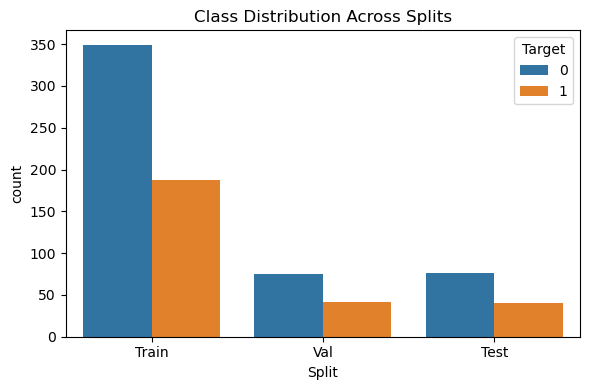

In [9]:
plot_split_distribution(y_train, y_val, y_test)

In [10]:
def EvaluateModel(
    y_pred: Union[np.ndarray, list],
    y_proba: Union[np.ndarray, list],
    y_test: Union[np.ndarray, list],
    model_name: str = "Model"
) -> pd.DataFrame:
    """
    Evaluate a binary classification model by calculating performance metrics,
    plotting the ROC curve and confusion matrix, and returning a metrics summary.

    Args:
        y_pred (array-like): Binary predicted labels (0 or 1).
        y_proba (array-like): Predicted probabilities for the positive class.
        y_test (array-like): True binary labels.
        model_name (str): Name or label of the model (included in the result).

    Returns:
        pd.DataFrame: A one-row DataFrame with evaluation metrics and the model name.
    """
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Specificity": SPECIFICITY(y_test, y_pred),  # funzione definita a parte
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

    print(f"\n📊 Evaluation metrics for '{model_name}':")
    for name, value in metrics.items():
        if name != "Model":
            print(f"{name}: {value:.3f}")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label="ROC curve")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {model_name}")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return pd.DataFrame([metrics])


In [11]:
def summarize_layers(model: Union[Model, object], model_name:str = 'model') -> pd.DataFrame:
    """
    Extracts a detailed layer-by-layer summary from a compiled Keras model
    and returns it as a pandas DataFrame.
    Parameters:
        model: A compiled and built Keras model (instance of keras.Model)
    Returns:
        A pandas DataFrame containing:
            - Layer name
            - Layer type
            - Output shape
            - Activation function
            - Units (for Dense) or filters (for Conv)
            - Trainable status
            - Number of parameters
    """
    summary = []

    # 🔁 Loop through all layers in the model
    for layer in model.layers:
        # Get the layer configuration dictionary
        config = layer.get_config()

        # Collect useful information for each layer
        layer_info = {
            "Model Name": model_name,
            "Layer Name": layer.name,
            "Layer Type": layer.__class__.__name__,
            "Output Shape": layer.output_shape if hasattr(layer, 'output_shape') else 'N/A',
            "Activation": config.get("activation", "N/A"),  # Only available in activatable layers
            "Units/Filters": config.get("units", config.get("filters", "N/A")),  # Dense or Conv
            "Params": layer.count_params(),
            "Trainable": layer.trainable
        }
        if isinstance(layer, tf.keras.layers.Dropout):
           layer_info["Dropout Rate"] = layer.rate
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer_info["Momentum"] = layer.momentum
            layer_info["Epsilon"] = layer.epsilon

        # Append the layer info to the summary list
        summary.append(layer_info)
   
    # 📊 Convert the list of dictionaries to a pandas DataFrame and return it
    return pd.DataFrame(summary)

In [12]:
def summarize_model(model, name='Model'):
    """
    Extracts summary info from a compiled Keras model:
    - Counts the number of Dense layers
    - Sums the total number of neurons across Dense layers
    - Retrieves total, trainable, and non-trainable parameters
    Returns the info as a one-row pandas DataFrame.
    """
    # ✅ Ensure the model is built before accessing layer properties like shapes or units
    if not model.built:
        try:
            model.build(input_shape=(None, 8))  # Build with a default input shape if needed
        except:
            pass  # Ignore if the model is already built via training or fitting

    n_layers = 0      # To count how many Dense layers the model has
    n_neurons = 0     # To accumulate the number of neurons in those layers

    # 🔁 Loop through all layers in the model
    for layer in model.layers:
        # Check if the layer is a Dense (fully connected) layer
        if isinstance(layer, Dense):
            n_layers += 1
            try:
                n_neurons += layer.units  # Safely access the number of neurons
            except:
                pass  # In case the layer is not fully built yet
            
    # 🔢 Total number of parameters in the model
    total_params = model.count_params()

    # 🔢 Sum the number of trainable parameters using backend utility
    trainable_params = int(sum(K.count_params(w) for w in model.trainable_weights))

    # 🚫 Non-trainable = total - trainable (e.g., from batch norm moving averages)
    non_trainable_params = total_params - trainable_params

    # 📋 Return all collected info as a one-row DataFrame
    return pd.DataFrame([{
        "Model": name,
        "Layers": n_layers,
        "Neurons": n_neurons,
        "Total Params": total_params,
        "Trainable Params": trainable_params,
        "Non-Trainable Params": non_trainable_params
    }])
  

<section>
  <p style="text-align:justify;">   
    The <strong><i>create_model</i></strong> function should be designed to accept all the parameters you intend to tune. However, optimizing too many hyperparameters simultaneously leads to an explosion in the number of possible combinations, which can be computationally infeasible. 
    In practice, it's better to adopt a more efficient tuning strategy:
  </p>

  <ul>
    <li>Start by tuning only a few key hyperparameters</li>
    <li>Use <code>RandomizedSearchCV</code> instead of <code>GridSearchCV</code> when exploring large parameter spaces</li>
    <li>Apply a sequential search strategy (tune some parameters, fix their values, then tune others)</li>
  </ul>

  <p style="text-align:justify;">
    Below is a comprehensive example of a parameter grid written as a Python dictionary:
  </p>

  <pre><code style="color: green;">
param_grid = {

    # StandardScaler parameters
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],

    # Neural network training parameters
    'nn__batch_size': [16, 32, 64],
    'nn__epochs': [50, 100],
    'nn__optimizer': ['adam', 'rmsprop', 'sgd'],
    'nn__learning_rate': [0.001, 0.01],
    'nn__validation_split': [0.1, 0.2],

    # Neural network architecture parameters
    'nn__model__units': [32, 64, 128],  # Requires support in create_model
    'nn__model__activation': ['relu', 'tanh', 'elu'],
    'nn__model__dropout_rate': [0.2, 0.3, 0.5],
    'nn__model__l1_val': [0.0, 0.0001],
    'nn__model__l2_val': [0.0001, 0.001],
    'nn__model__init': ['glorot_uniform', 'he_normal', 'random_normal'],
    'nn__model__layers': [1, 2, 3],  # Requires support in create_model
    'nn__model__use_bias': [True, False],

    # Compile parameters
    'nn__model__loss': ['binary_crossentropy', 'mean_squared_error'],
    'nn__model__metrics': [['accuracy'], ['accuracy', 'AUC']]  # Requires support in create_model
}
  </code></pre> 
</section>




 <p style="color: blue; font-weight: bold; font-size: 26px; font-family: 'Arial', sans-serif; text-decoration: underline;">Configuring the Search Space</p>

In [13]:
"""
The search space define our startegy:
having a smal and non complex dataset we  chose low epochs values, and a very  small layers
"""
def make_earlystop(patience):
    return [EarlyStopping(monitor='val_AUC', patience=patience, mode='max', restore_best_weights=True)]

param_grid = {
    'nn__batch_size': [16, 32],
    'nn__epochs': [30, 50],
    'nn__optimizer':['adam', 'rmsprop'],
    'nn__model__init': ['glorot_uniform'],
    'nn__model__dropout_rate': [0.0, 0.1],
    'nn__model__l2_val': [0.0, 0.0001],
    'nn__model__tipo': [1],  # Switch the operating mode of the create_model function
    'nn__model__hidden_layers': [[5], [5,4]],
    'nn__callbacks': [make_earlystop(p) for p in [3, 5]]
}

In [14]:
# Function to create a Keras Sequential model with configurable architecture
def create_model(
    optimizer='adam',              # Optimizer to use (default: Adam)
    init='glorot_uniform',         # Weight initialization method
    dropout_rate=0.1,              # Dropout rate for regularization
    l2_val=0.001,                  # L2 regularization value
    input_shape=(8,),              # Shape of the input layer
    tipo=1,                        # Architecture type: 0 = uniform layers, 1 = custom layer sizes
    num_layers=2,                  # Number of layers (used if tipo == 0)
    units_per_layer=5,             # Number of neurons per layer (used if tipo == 0)
    hidden_layers=[6, 4, 2]        # List defining units in each hidden layer (used if tipo == 1)
):
    model = Sequential()           # Initialize a sequential model
    model.add(Input(shape=input_shape))  # Add input layer with given shape

    if tipo == 0:
        # If tipo == 0: build a uniform model with identical layers
        for _ in range(num_layers):
            model.add(Dense(units_per_layer, kernel_initializer=init,
                            activation='relu', kernel_regularizer=l2(l2_val)))
            model.add(BatchNormalization())  # Normalize activations
            model.add(Dropout(dropout_rate)) # Dropout for regularization
    else:
        # If tipo == 1: build a custom model using hidden_layers list
        for units in hidden_layers:
            model.add(Dense(units, kernel_initializer=init,
                            activation='relu', kernel_regularizer=l2(l2_val)))
            model.add(BatchNormalization())
            model.add(Dropout(dropout_rate))

    # Output layer with 1 neuron and sigmoid activation for binary classification
    model.add(Dense(1, kernel_initializer=init, activation='sigmoid'))
    # Compile the model with binary cross-entropy loss and AUC as a metric
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy', Precision(name='precision'),
                   Recall(name='recall'), AUC(name='AUC')])
    return model

In [15]:
def hyperparameters_tuning(
    pipeline,
    search_space: dict,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    search_function=GridSearchCV,
    cv: int = 3) -> dict:
    """
    Performs hyperparameter tuning with cross-validation 
    and evaluates model performance.
    Args:
        pipeline: The scikit-learn pipeline to use
        search_space: Dictionary with parameters names 
        (will be used as param_grid or param_distributions dependig on the search_function)
        X_train: Training features
        y_train: Training labels
        X_val: Validation features
        y_val: Validation labels
        search_function: Search function to use (GridSearchCV or RandomizedSearchCV)
        cv: Number of cross-validation folds (default: 3)
        **search_kwargs: Additional keyword arguments for the search function

    Returns:
        dict: Dictionary containing best parameters, performance metrics, and fitted model
    """
    
    # Determine the correct parameter name based on the search function
    param_name = 'param_distributions' if search_function.__name__ == 'RandomizedSearchCV' else 'param_grid'
    
    # Create parameters dictionary
    search_params = {'estimator': pipeline,'cv': cv,'scoring': 'roc_auc', 'n_jobs': -1 }
   
    # Add the appropriate parameter options with the correct key name
    search_params[param_name] = search_space
 
    # Initialize and fit search
    model = search_function(**search_params)
    model_result = model.fit(X_train, y_train)
        
    # Make predictions
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred = y_proba > 0.5
    
    # Calculate performance metrics
    results = {
        'best_params': model_result.best_params_,
        'best_score': model_result.best_score_,
        'accuracy': accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall': recall_score(y_val, y_pred),
        'specificity': SPECIFICITY(y_val, y_pred),
        'f1_score': f1_score(y_val, y_pred),
        'auc': roc_auc_score(y_val, y_proba),
        'model': model,
        'model_results':model_result,
        'y_pred':y_pred,
        'y_proba':y_proba
       }
    
    return  results


<ol start = 1 style="list-style-type: decimal;">
  <li style="color: blue; font-weight: bold; font-size: 26px; font-family: 'Arial', sans-serif;">Grid Search</li>
</ol>

Selected Hyperparameters:

nn__batch_size: 16
🧠 EarlyStopping config:
  monitor: val_AUC
  patience: 5
  mode: max
  restore_best_weights: True
nn__epochs: 50
nn__model__dropout_rate: 0.0
nn__model__hidden_layers: [5, 4]
nn__model__init: glorot_uniform
nn__model__l2_val: 0.0
nn__model__tipo: 1
nn__optimizer: adam

📊 Evaluation metrics for 'grid_results':
Accuracy: 0.733
Precision: 0.632
Recall: 0.585
Specificity: 0.813
F1 Score: 0.608
AUC: 0.786


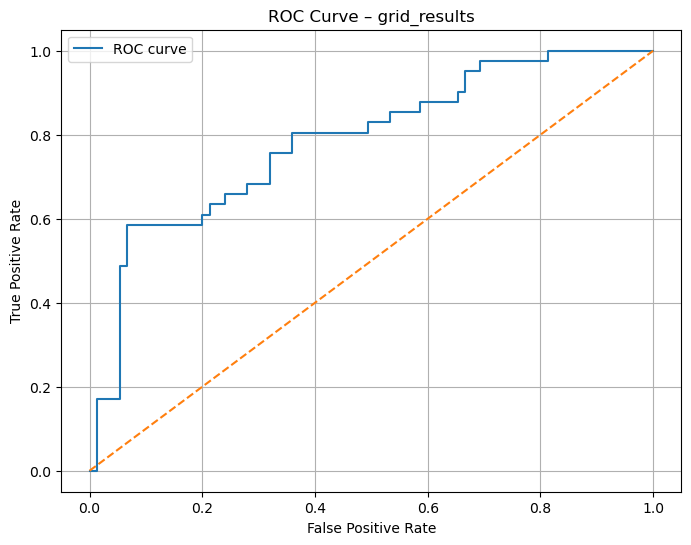

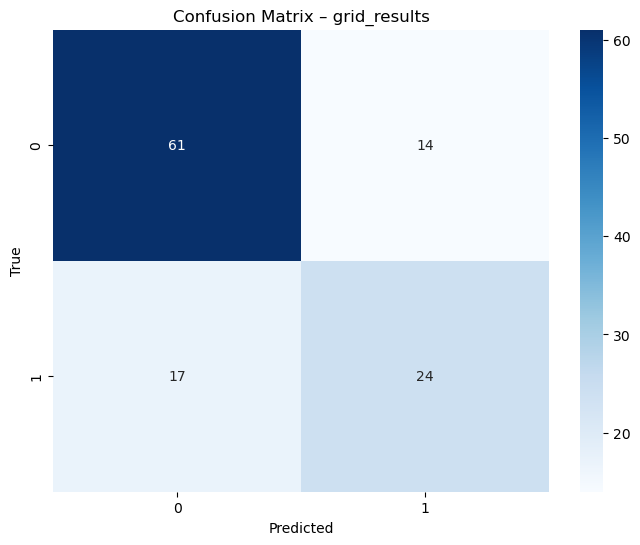


📋 Best Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 5)                   │              20 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 4)                   │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 296 (1.16 KB)

 Trainable params: 92 (368.00 B)

...

🧱 Layer Summary:


,Model Name,Layer Name,Layer Type,Output Shape,Activation,Units/Filters,Params,Trainable,Momentum,Epsilon,Dropout Rate
0,grid_results,dense,Dense,N/A,relu,5,45,True,NaN,NaN,NaN
1,grid_results,batch_normalization,BatchNormalization,N/A,N/A,N/A,20,True,0.99,0.001,NaN
2,grid_results,dropout,Dropout,N/A,N/A,N/A,0,True,NaN,NaN,0.0
3,grid_results,dense_1,Dense,N/A,relu,4,24,True,NaN,NaN,NaN
4,grid_results,batch_normalization_1,BatchNormalization,N/A,N/A,N/A,16,True,0.99,0.001,NaN
5,grid_results,dropout_1,Dropout,N/A,N/A,N/A,0,True,NaN,NaN,0.0
6,grid_results,dense_2,Dense,N/A,sigmoid,1,5,True,NaN,NaN,NaN


🧱 Model Performance:


,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,grid_results,0.732759,0.631579,0.585366,0.813333,0.607595,0.786016


Execution time: 0h 23m 33.71s


In [16]:
start_time = time.time()
############################################################################################################
# Execute grid search and get results in grid_results dictionary
# Wrap the Keras model for use in scikit-learn-compatible pipelines
# ✅ 'validation_split' è necessario per calcolare val_AUC

model = KerasClassifier(model=create_model, validation_split=0.1, verbose=0)  
# Define a pipeline with standard scaling and the neural network model
pipeline = Pipeline([('scaler', StandardScaler()),  ('nn', model) ])
grid_results = hyperparameters_tuning(pipeline,param_grid,X_train,y_train, X_val,y_val,GridSearchCV, cv = 3) 
############################################################################################################
y_proba_grid = grid_results['y_proba']
y_pred_grid = grid_results['y_pred']

# Display best hyperparameters
print("Selected Hyperparameters:\n")
for key, value in grid_results['model'].best_params_.items():
   if key != 'nn__callbacks' :
     print(f"{key}: {value}")
   elif key == 'nn__callbacks' : 
     early = grid_results['model'].best_params_['nn__callbacks'][0]
     print("🧠 EarlyStopping config:")
     print(f"  monitor: {early.monitor}")
     print(f"  patience: {early.patience}")
     print(f"  mode: {early.mode}")
     print(f"  restore_best_weights: {early.restore_best_weights}")

name = "grid_results"
best_model_grid = grid_results['model'].best_estimator_.named_steps['nn'].model_
model_df_grid = summarize_model(best_model_grid, name)
layers_df_grid = summarize_layers(best_model_grid, name)
ModelEval=EvaluateModel(y_pred_grid, y_proba_grid, y_val, name)

try:
    print("\n📋 Best Model Summary:")
    best_model_grid.summary()
except Exception as e:
    print(f"⚠️ Cannot display model summary: {e}")

print("📋 Model Summary:")
display(model_df_grid)

print("🧱 Layer Summary:")
display(layers_df_grid)

print("🧱 Model Performance:")
display(ModelEval)

# End timing and format in hours, minutes, seconds
end_time = time.time()
elapsed_time = end_time - start_time
hours, remainder = divmod(elapsed_time, 3600)
minutes, seconds = divmod(remainder, 60)
print(f"Execution time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")


<ol start = 2 style="list-style-type: decimal;">
  <li style="color: blue; font-weight: bold; font-size: 26px; font-family: 'Arial', sans-serif;">Randomized Search</li>
</ol>

Selected Hyperparameters:

nn__optimizer: adam
nn__model__tipo: 1
nn__model__l2_val: 0.0
nn__model__init: glorot_uniform
nn__model__hidden_layers: [5]
nn__model__dropout_rate: 0.0
nn__epochs: 50
🧠 EarlyStopping config:
  monitor: val_AUC
  patience: 5
  mode: max
  restore_best_weights: True
nn__batch_size: 16

📊 Evaluation metrics for 'rand_results':
Accuracy: 0.750
Precision: 0.650
Recall: 0.634
Specificity: 0.813
F1 Score: 0.642
AUC: 0.782


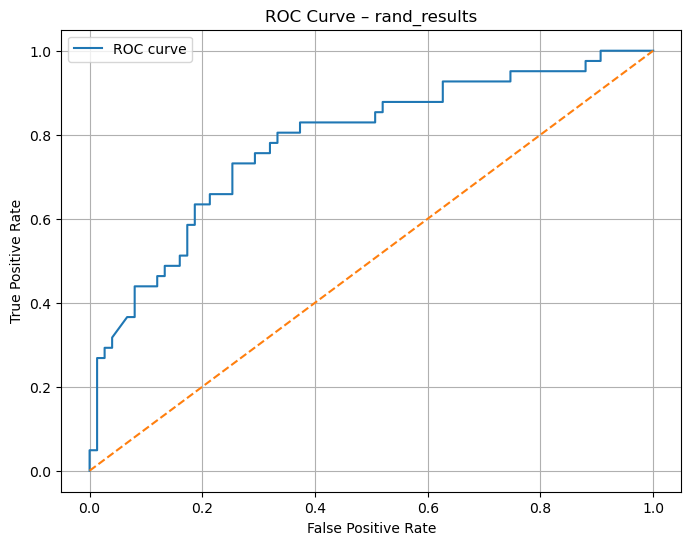

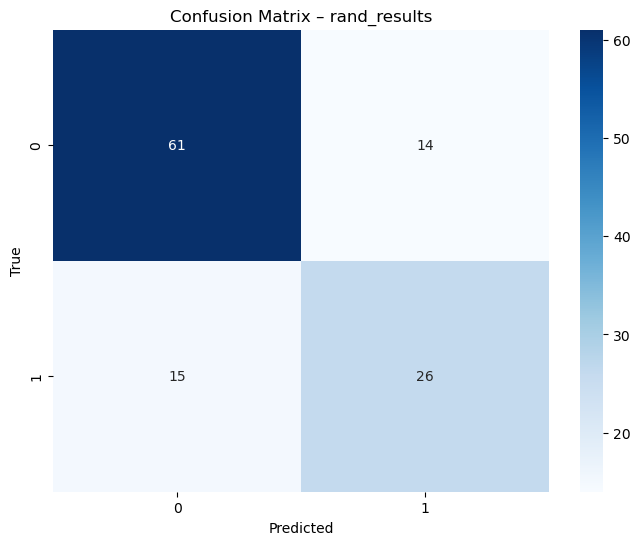


📋 Best Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 5)                   │              45 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 5)                   │              20 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 195 (784.00 B)

 Trainable params: 61 (244.00 B)

...

🧱 Layer Summary:


,Model Name,Layer Name,Layer Type,Output Shape,Activation,Units/Filters,Params,Trainable,Momentum,Epsilon,Dropout Rate
0,rand_results,dense_3,Dense,N/A,relu,5,45,True,NaN,NaN,NaN
1,rand_results,batch_normalization_2,BatchNormalization,N/A,N/A,N/A,20,True,0.99,0.001,NaN
2,rand_results,dropout_2,Dropout,N/A,N/A,N/A,0,True,NaN,NaN,0.0
3,rand_results,dense_4,Dense,N/A,sigmoid,1,6,True,NaN,NaN,NaN


🧱 Model Performance:


,Model,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
0,rand_results,0.75,0.65,0.634146,0.813333,0.641975,0.781789


Execution time: 0h 2m 7.47s


In [17]:
start_time = time.time()
############################################################################################################
# Execute random search and get results in rand_results dictionary
model = KerasClassifier(model=create_model, validation_split=0.1, verbose=0)  
pipeline = Pipeline([('scaler', StandardScaler()), ('nn', model)])
rand_results = hyperparameters_tuning(pipeline,param_grid,X_train,y_train, X_val,y_val,RandomizedSearchCV, cv = 3) 
############################################################################################################
y_proba_rand = rand_results['y_proba']
y_pred_rand = rand_results['y_pred']
# Display Hyperparameters & model summary
print("Selected Hyperparameters:\n")
for key, value in rand_results['model'].best_params_.items():
   if key != 'nn__callbacks' :
     print(f"{key}: {value}")
   elif key == 'nn__callbacks' : 
     early = rand_results['model'].best_params_['nn__callbacks'][0]
     print("🧠 EarlyStopping config:")
     print(f"  monitor: {early.monitor}")
     print(f"  patience: {early.patience}")
     print(f"  mode: {early.mode}")
     print(f"  restore_best_weights: {early.restore_best_weights}")

name = "rand_results"
best_model_rand = rand_results['model'].best_estimator_.named_steps['nn'].model_
model_df_rand = summarize_model(best_model_rand, name)
layers_df_rand = summarize_layers(best_model_rand, name)
ModelEval=EvaluateModel(y_pred_rand, y_proba_rand, y_val, name)

try:
    print("\n📋 Best Model Summary:")
    best_model_rand.summary()
except Exception as e:
    print(f"⚠️ Cannot display model summary: {e}")

print("📋 Model Summary:")
display(model_df_rand)
print("🧱 Layer Summary:")
display(layers_df_rand)
print("🧱 Model Performance:")
display(ModelEval)

# End timing 
end_time = time.time()
elapsed_time = end_time - start_time
hours, remainder = divmod(elapsed_time, 3600)
minutes, seconds = divmod(remainder, 60)
print(f"Execution time: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

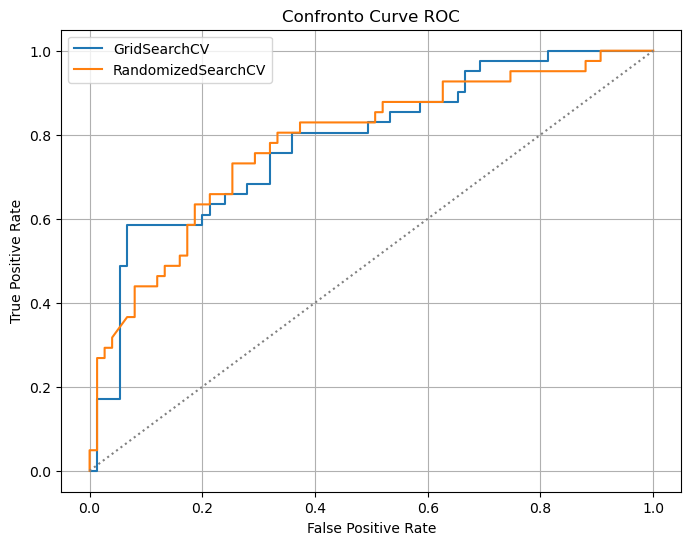

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcolo ROC
fpr_grid, tpr_grid, _ = roc_curve(y_val, y_proba_grid)
fpr_rand, tpr_rand, _ = roc_curve(y_val, y_proba_rand)

# Plot delle curve ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_grid, tpr_grid, label='GridSearchCV')
plt.plot(fpr_rand, tpr_rand, label='RandomizedSearchCV')
plt.plot([0, 1], [0, 1], linestyle=':', color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Confronto Curve ROC")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
comparison = {
        'grid':{
        "Accuracy": accuracy_score(y_val, y_pred_grid),
        "Precision": precision_score(y_val, y_pred_grid),
        "Recall": recall_score(y_val, y_pred_grid),
        "Specificity": SPECIFICITY(y_val, y_pred_grid),
        "F1 Score": f1_score(y_val, y_pred_grid),
        "AUC": roc_auc_score(y_val, y_proba_grid)
        },
     'rand':{
        "Accuracy": accuracy_score(y_val, y_pred_rand),
        "Precision": precision_score(y_val, y_pred_rand),
        "Recall": recall_score(y_val, y_pred_rand),
        "Specificity": SPECIFICITY(y_val, y_pred_rand),
        "F1 Score": f1_score(y_val, y_pred_rand),
        "AUC": roc_auc_score(y_val, y_proba_rand)
        }
    
    }

In [20]:
# Convert the comparison dictionary to a DataFrame
comparison_df = pd.DataFrame(comparison).T

# Display as percentages with 2 decimal places (but keep numeric values)
comparison_df = comparison_df.style.format("{:.2%}").highlight_max(axis=0, color='lightgreen')

models ={
    'best_model_grid':grid_results['model'].best_estimator_.named_steps['nn'].model_,
    'best_model_rand':rand_results['model'].best_estimator_.named_steps['nn'].model_
   
}
summaries = []
for name, model in models.items():
    summary_df = summarize_model(model, name)
    summaries.append(summary_df)

summary_table = pd.concat(summaries, ignore_index=True)

summaries = []
for name, model in models.items():
    summary_df = summarize_layers(model, name)
    summaries.append(summary_df)

summary_table_2 = pd.concat(summaries, ignore_index=True)
summary_table_2 = summary_table_2.drop(columns=["Output Shape", "Activation"], errors='ignore')

In [21]:
print("📋 Model Comparison- performance measures - :")
display(comparison_df)

print("📋 Model Comparison:")
display(summary_table)

print("🧱 Model Comparison with layers structure:")
display(summary_table_2)


📋 Model Comparison- performance measures - :


,Accuracy,Precision,Recall,Specificity,F1 Score,AUC
grid,73.28%,63.16%,58.54%,81.33%,60.76%,78.60%
rand,75.00%,65.00%,63.41%,81.33%,64.20%,78.18%


📋 Model Comparison:


,Model,Layers,Neurons,Total Params,Trainable Params,Non-Trainable Params
0,best_model_grid,3,10,110,92,18
1,best_model_rand,2,6,71,61,10


🧱 Model Comparison with layers structure:


,Model Name,Layer Name,Layer Type,Units/Filters,Params,Trainable,Momentum,Epsilon,Dropout Rate
0,best_model_grid,dense,Dense,5,45,True,NaN,NaN,NaN
1,best_model_grid,batch_normalization,BatchNormalization,N/A,20,True,0.99,0.001,NaN
2,best_model_grid,dropout,Dropout,N/A,0,True,NaN,NaN,0.0
3,best_model_grid,dense_1,Dense,4,24,True,NaN,NaN,NaN
4,best_model_grid,batch_normalization_1,BatchNormalization,N/A,16,True,0.99,0.001,NaN
5,best_model_grid,dropout_1,Dropout,N/A,0,True,NaN,NaN,0.0
6,best_model_grid,dense_2,Dense,1,5,True,NaN,NaN,NaN
7,best_model_rand,dense_3,Dense,5,45,True,NaN,NaN,NaN
8,best_model_rand,batch_normalization_2,BatchNormalization,N/A,20,True,0.99,0.001,NaN
9,best_model_rand,dropout_2,Dropout,N/A,0,True,NaN,NaN,0.0
